In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.cluster import KMeans

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("referees.csv")
df.head()

,key_id,referee_id,family_name,given_name,female,country_name,confederation_id,confederation_name,confederation_code,referee_wikipedia_link
0,1,R-001,Abdel-Fatah,Essam,0,Egypt,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Essam_Abd_El_Fatah
1,2,R-002,Abidoye,Bola Elizabeth,1,Nigeria,CF-2,Confederation of African Football,CAF,not available
2,3,R-003,Adair,John,0,Northern Ireland,CF-6,Union of European Football Associations,UEFA,not available
3,4,R-004,Adámková,Jana,1,Czech Republic,CF-6,Union of European Football Associations,UEFA,https://en.wikipedia.org/wiki/Jana_Ad%C3%A1mko...
4,5,R-005,Agboyi,Xonam,1,Togo,CF-2,Confederation of African Football,CAF,not available


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(493, 10)
<class 'pandas.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   key_id                  493 non-null    int64
 1   referee_id              493 non-null    str  
 2   family_name             493 non-null    str  
 3   given_name              493 non-null    str  
 4   female                  493 non-null    int64
 5   country_name            493 non-null    str  
 6   confederation_id        493 non-null    str  
 7   confederation_name      493 non-null    str  
 8   confederation_code      493 non-null    str  
 9   referee_wikipedia_link  493 non-null    str  
dtypes: int64(2), str(8)
memory usage: 93.8 KB
None
key_id                    0
referee_id                0
family_name               0
given_name                0
female                    0
country_name              0
confederation_id          0
confederation_name        0
confeder

In [4]:
df.describe()

,key_id,female
count,493.000000,493.000000
mean,247.000000,0.166329
std,142.461106,0.372754
min,1.000000,0.000000
25%,124.000000,0.000000
50%,247.000000,0.000000
75%,370.000000,0.000000
max,493.000000,1.000000


In [6]:
df = df.copy()
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').astype('string')

for col in df.select_dtypes(include='string').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [8]:
if target_column in df.columns:
    X = df.drop(columns=[target_column])
    y = df[target_column]
else:
    print("Target column not found. Available columns:", df.columns)

Target column not found. Available columns: Index(['key_id', 'referee_id', 'family_name', 'given_name', 'female',
       'country_name', 'confederation_id', 'confederation_name',
       'confederation_code', 'referee_wikipedia_link'],
      dtype='str')


In [9]:
[col for col in df.columns if "dec" in col.lower()]

[]

In [11]:
print(df.columns)

Index(['key_id', 'referee_id', 'family_name', 'given_name', 'female',
       'country_name', 'confederation_id', 'confederation_name',
       'confederation_code', 'referee_wikipedia_link'],
      dtype='str')


In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data      # features
y = data.target    # labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
et = ExtraTreesClassifier(n_estimators=200, random_state=42)
et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred_et))
print(classification_report(y_test, y_pred_et))

Extra Trees Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [16]:
print('text_cols' in locals())

False


In [17]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'train_test_split', 'LabelEncoder', 'StandardScaler', 'RandomForestClassifier', 'ExtraTreesClassifier', 'KMeans', 'TfidfVectorizer', 'PCA', 'accuracy_score', 'classification_report', '_i2', 'df', '_2', '_i3', '_i4', '_4', '_i5', 'label_encoders', 'col', 'le', '_i6', '_i7', 'target_column', '_i8', '_i9', '_9', '_i10', '_i11', '_i12', '_i13', 'load_iris', 'data', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', '_i14', 'et', 'y_pred_et', '_i15', '_i16', '_i17'])


In [19]:
print(df.columns)

Index(['key_id', 'referee_id', 'family_name', 'given_name', 'female',
       'country_name', 'confederation_id', 'confederation_name',
       'confederation_code', 'referee_wikipedia_link'],
      dtype='str')


In [21]:
print('X_text' in globals())

False


In [23]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(150, 4)


In [24]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(150, 4)


In [27]:

df.head()

,key_id,referee_id,family_name,given_name,female,country_name,confederation_id,confederation_name,confederation_code,referee_wikipedia_link
0,1,0,0,119,0,22,1,1,1,108
1,2,1,1,57,1,57,1,1,1,368
2,3,2,2,211,0,59,5,5,5,368
3,4,3,3,199,1,17,5,5,5,175
4,5,4,4,405,1,85,1,1,1,368


In [30]:
df = df.dropna()

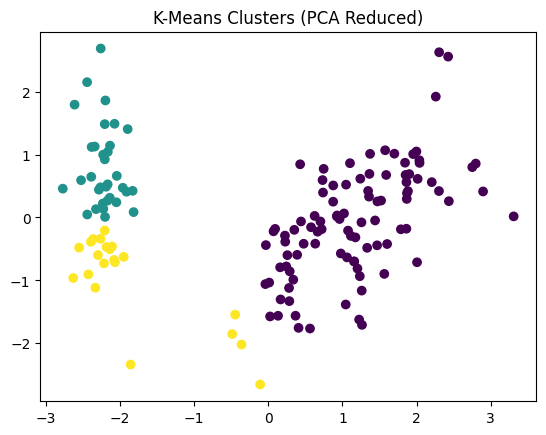

In [31]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.scatter(components[:,0], components[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [36]:
'feat_df' in globals()

False